#Model analisis sentimen ulasan aplikasi Shoppe - Laila Dwi Kartika Sari

Melakukan import library yang dibutuhkan untuk keseluruhan proyek.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import re
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import download as nltk_download
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score
from sklearn.preprocessing import LabelEncoder

# Model LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Conv1D, GlobalMaxPooling1D, Bidirectional, MaxPooling1D, Flatten, GRU, SimpleRNN
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

import requests
import csv
from io import StringIO
import tensorflow as tf

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Memuat dataset

1. Melakukan read dataset dan menyimpannya di variabel data.
2. Menampilkan lima data teratas dari dataset.

In [3]:
# Read dataset
data = pd.read_csv('/content/HasilScraping_ulasan_aplikasi_ Shopee.csv')

# Menampilkan lima data teratas.
data.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,9361e1fb-9ab6-4fd7-8b05-bd93d5ffb15d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Dari semua aplikasi online shop shopee is the ...,5,33,3.44.26,2025-03-08 01:41:02,"Hai kak Lies Murtiana , mksih ya buat bintang ...",2025-03-08 02:18:48,3.44.26
1,a76b9700-e40b-4820-98a3-7980e0164b68,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,(Saran dari saya ya min) disaat paket sudah di...,5,2623,3.44.26,2025-03-08 02:33:33,"Hai kakak Zaenal Abidin , maaf ya terkait deng...",2025-03-08 03:52:33,3.44.26
2,ce84745b-af08-40fe-801f-a1cbfa39578e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,menurut sy aplikasih shoppe ini sangat membant...,5,891,3.44.26,2025-03-09 16:11:27,"Hai kak Diana Wahyu, maaf ya udah buat kamu ng...",2025-03-09 18:19:27,3.44.26
3,1af128b7-85c4-49d3-b19b-b5047305d9a6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Pengiriman spx lambat sekali, tolong di perbai...",5,1058,3.44.26,2025-03-09 04:56:27,"Hai kak Remodjemod, mohon maaf atas ketidaknya...",2025-03-01 13:08:48,3.44.26
4,91ad9faf-f5ca-471a-8965-830f785f134a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi blanja online yg selalu ku pake. Muda...,5,272,3.44.26,2025-03-08 04:55:48,"Hai kak Evilica , thanks ya bintang dan ulasa...",2025-03-08 06:52:22,3.44.26


3. Menampilkan lima data terakhir dari dataset.

In [4]:
# Menampilkan lima data terakhir
data.tail()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
29995,f038a3a9-a77e-4270-8981-8bad0145eed9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi mantap sangat membantu dalam belanja ...,5,1,2.84.31,2022-03-31 15:40:40,NaN,NaN,2.84.31
29996,4c9ac9d1-24ef-4645-af36-1f604eda30c8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Suka banget sama shopee ,awal download bingung...",5,0,2.60.12,2020-10-08 07:24:05,Horee thanks ya kak buat ratingnya. Aku tuh se...,2020-10-08 08:22:34,2.60.12
29997,3079f72e-31d3-4a23-88e3-48d152c52c32,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Belanja di shopee mudah , gak ribet.. tapi say...",5,5,2.61.11,2020-10-24 06:11:46,"Hai kak, maaf banget ya buat kendala kamu. Mim...",2020-10-24 07:06:57,2.61.11
29998,2c663447-9ed0-42fd-b5ca-3e463aac345a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,pengalaman belanja kurang nyaman karna ada sel...,5,0,2.65.16,2024-07-29 05:20:10,"Hi ka, mksi bintang 5ny & maaf bikin ga nyaman...",2024-07-29 06:59:26,2.65.16
29999,2f7e3052-367b-4e05-9fd1-460088032f98,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,apk ini bagus banget buat kita yang mau belanj...,5,0,2.69.20,2021-04-16 05:32:27,NaN,NaN,2.69.20


4. Menampilkan informasi dari dataset seperti jumlah baris, kolom, dan tipe data.

In [5]:
# Menampilkan info dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              30000 non-null  object
 1   userName              30000 non-null  object
 2   userImage             30000 non-null  object
 3   content               30000 non-null  object
 4   score                 30000 non-null  int64 
 5   thumbsUpCount         30000 non-null  int64 
 6   reviewCreatedVersion  27491 non-null  object
 7   at                    30000 non-null  object
 8   replyContent          23558 non-null  object
 9   repliedAt             23558 non-null  object
 10  appVersion            27491 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.5+ MB


# Data preparation


1. Menghapus missing value pada kolom content karena hanya kolom inilah yang akan digunakan untuk pelatihan model dan menghapus data yang duplikat.

In [6]:
# Menghapus missing value pada kolom 'content'
clean_data = data.dropna(subset=['content'])

# Menghapus data duplikat
clean_data = clean_data.drop_duplicates()

2. Menampilkan kembali info dari dataset setelah dilakukan cleaning.

In [7]:
# Menampilkan info dataset
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              30000 non-null  object
 1   userName              30000 non-null  object
 2   userImage             30000 non-null  object
 3   content               30000 non-null  object
 4   score                 30000 non-null  int64 
 5   thumbsUpCount         30000 non-null  int64 
 6   reviewCreatedVersion  27491 non-null  object
 7   at                    30000 non-null  object
 8   replyContent          23558 non-null  object
 9   repliedAt             23558 non-null  object
 10  appVersion            27491 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.5+ MB


3. Mendefinisikan fungsi-fungsi untuk preprocessing text.

  - cleaningText: fungsi untuk menghapus mentions, hastag, RT, link, dan numbers dari text.
  - caseFfoldingText: fungsi untuk mengubah text menjadi lowercase.
  tokenizingText: fungsi untuk memecah text menjadi list tokens.
  - filteringText: fungsi untuk menghapus stopwords dalam bahasa Indonesia ataupun Inggris.
  - stemmingText: fungsi untuk mengubah text menjadi bentuk dasar. Namun pada proyek ini tidak akan digunakan karena proses nya yang lama.
  - toSentence: fungsi untuk menggabungkan kembali text yang sebelumnya dipecah menjadi token.

In [8]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)  # Hapus mention (@username)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)  # Hapus hashtag (#tagar)
    text = re.sub(r'RT[\s]', '', text)  # Hapus retweet (RT)
    text = re.sub(r"http\S+", '', text)  # Hapus tautan (link)
    text = re.sub(r'[0-9]+', '', text)  # Hapus angka
    text = re.sub(r'[^\w\s]', '', text)  # Hapus karakter non-alfanumerik
    text = text.replace('\n', ' ')  # Ganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation))  # Hapus tanda baca
    text = text.strip()  # Hapus spasi berlebih di awal dan akhir teks
    return text


In [9]:
def casefoldingText(text):
    text = text.lower()  # Mengubah seluruh teks menjadi huruf kecil
    return text

In [10]:
def tokenizingText(text):
    text = word_tokenize(text)  # Memecah teks menjadi kata-kata (tokenisasi)
    return text

In [11]:
def filteringText(text):
     # Mengambil daftar stopwords dalam bahasa Indonesia dan Inggris
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))

    # Menggabungkan stopwords dari kedua bahasa
    listStopwords.update(listStopwords1)

    # Menambahkan kata-kata tambahan yang dianggap tidak memiliki makna penting
    listStopwords.update(['iya', 'yaa', 'gak', 'nya', 'na', 'sih', 'ku', "di", "ga", "ya", "gaa", "loh", "kah", "woi", "woii", "woy"])

    # Menghapus kata-kata yang termasuk dalam daftar stopwords
    filtered = [txt for txt in text if txt not in listStopwords]

    return filtered  # Mengembalikan teks yang telah difilter

In [12]:
def stemmingText(text):
    factory = StemmerFactory()  # Membuat objek factory untuk stemming
    stemmer = factory.create_stemmer()  # Membuat objek stemmer dari factory

    words = text.split()  # Memisahkan teks menjadi daftar kata

    stemmed_words = [stemmer.stem(word) for word in words]  # Melakukan stemming pada setiap kata

    stemmed_text = ' '.join(stemmed_words)  # Menggabungkan kata-kata hasil stemming menjadi satu teks

    return stemmed_text  # Mengembalikan teks yang sudah melalui proses stemming


In [13]:
def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)  # Menggabungkan daftar kata menjadi satu kalimat dengan spasi
    return sentence  # Mengembalikan kalimat hasil penggabungan


4. Mendefinisikan fungsi untuk mengubah slangwords menjadi bentuk baku.

In [14]:
# Mendefinisikan fungsi untuk slangwords

slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}
def fix_slangwords(text):
    words = text.split()  # Memisahkan teks menjadi daftar kata
    fixed_words = []  # List untuk menyimpan kata yang sudah diperbaiki

    for word in words:
        if word.lower() in slangwords:  # Memeriksa apakah kata ada dalam daftar slangwords
            fixed_words.append(slangwords[word.lower()])  # Mengganti kata slang dengan kata baku
        else:
            fixed_words.append(word)  # Jika bukan slang, tambahkan kata asli

    fixed_text = ' '.join(fixed_words)  # Menggabungkan kata kembali menjadi teks
    return fixed_text  # Mengembalikan teks yang telah diperbaiki


5. Mendefinisikan clean_df sebagai dataframe yang sudah bersih.

In [15]:
# Menampilkan dataset yang belum dibersihkan
clean_df = clean_data  # Menyalin dataset asli ke dalam variabel clean_df
clean_df.head(1)  # Menampilkan satu baris pertama dari dataset

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,9361e1fb-9ab6-4fd7-8b05-bd93d5ffb15d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Dari semua aplikasi online shop shopee is the ...,5,33,3.44.26,2025-03-08 01:41:02,"Hai kak Lies Murtiana , mksih ya buat bintang ...",2025-03-08 02:18:48,3.44.26


6. Menerapkan preprocessing text pada dataset.

In [16]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

7. Menampilkan dataset setelah preprocessing text

In [17]:
# Menampilkan dataset setelah preprocessing text
clean_df.head(1)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,9361e1fb-9ab6-4fd7-8b05-bd93d5ffb15d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Dari semua aplikasi online shop shopee is the ...,5,33,3.44.26,2025-03-08 01:41:02,"Hai kak Lies Murtiana , mksih ya buat bintang ...",2025-03-08 02:18:48,3.44.26,Dari semua aplikasi online shop shopee is the ...,dari semua aplikasi online shop shopee is the ...,dari semua aplikasi online shop shopee is the ...,"[dari, semua, aplikasi, online, shop, shopee, ...","[aplikasi, online, shop, shopee, best, oneapli...",aplikasi online shop shopee best oneaplikasiny...


8. Mengunduh lexicon positive dan negative dari github.

In [18]:
# Loads positive lexicon data from GitHub
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()  # Membuat dictionary kosong untuk menyimpan kata-kata positif

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')  # Mengambil data dari GitHub
reader = csv.reader(StringIO(response.text), delimiter=',')  # Membaca isi file CSV
for row in reader:
    lexicon_positive[row[0]] = int(row[1])  # Menyimpan kata sebagai key dan nilai sebagai value dalam dictionary

# Loads negative lexicon data from GitHub
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()  # Membuat dictionary kosong untuk menyimpan kata-kata negatif

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')  # Mengambil data dari GitHub
reader = csv.reader(StringIO(response.text), delimiter=',')  # Membaca isi file CSV
for row in reader:
    lexicon_negative[row[0]] = int(row[1])  # Menyimpan kata sebagai key dan nilai sebagai value dalam dictionary


9. Mendefinisikan fungsi untuk menghitung polaritas sentimen.

In [19]:
# Fungsi untuk menentukan polaritas sentimen dari tweet
def sentiment_analysis_lexicon_indonesia(text):
    score = 0  # Inisialisasi skor sentimen

    for word in text:  # Mengulangi setiap kata dalam teks
        if word in lexicon_positive:
            score += lexicon_positive[word]  # Jika kata ada dalam kamus positif, tambahkan skornya

    for word in text:  # Mengulangi setiap kata dalam teks (sekali lagi)
        if word in lexicon_negative:
            score += lexicon_negative[word]  # Jika kata ada dalam kamus negatif, tambahkan skornya (seharusnya dikurangi)

    polarity = ''  # Inisialisasi variabel polaritas

    if score >= 0:
        polarity = 'positive'  # Jika skor lebih besar atau sama dengan 0, sentimen positif
    elif score <= -7:
        polarity = 'negative'  # Jika skor kurang dari atau sama dengan -7, sentimen negatif
    else:
        polarity = 'neutral'  # Jika tidak termasuk dalam kategori di atas, sentimen netral

    return score, polarity  # Mengembalikan skor sentimen dan polaritasnya


# Melakukan pelabelan data

1. Menghitung polaritas.

In [20]:
# Memberi label pada text
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)  # Menerapkan fungsi analisis sentimen ke setiap teks dalam kolom 'text_stopword'
results = list(zip(*results))  # Memisahkan hasil fungsi menjadi dua list terpisah (score dan polarity)
clean_df['polarity_score'] = results[0]  # Menyimpan skor sentimen ke dalam kolom 'polarity_score'
clean_df['polarity'] = results[1]  # Menyimpan label sentimen ('positive', 'neutral', 'negative') ke dalam kolom 'polarity'
print(clean_df['polarity'].value_counts())  # Menampilkan jumlah data untuk setiap kategori sentimen


polarity
positive    20997
neutral      6366
negative     2637
Name: count, dtype: int64


# Data understanding

1. Menampilkan distribusi polarity_score dengan histogram.

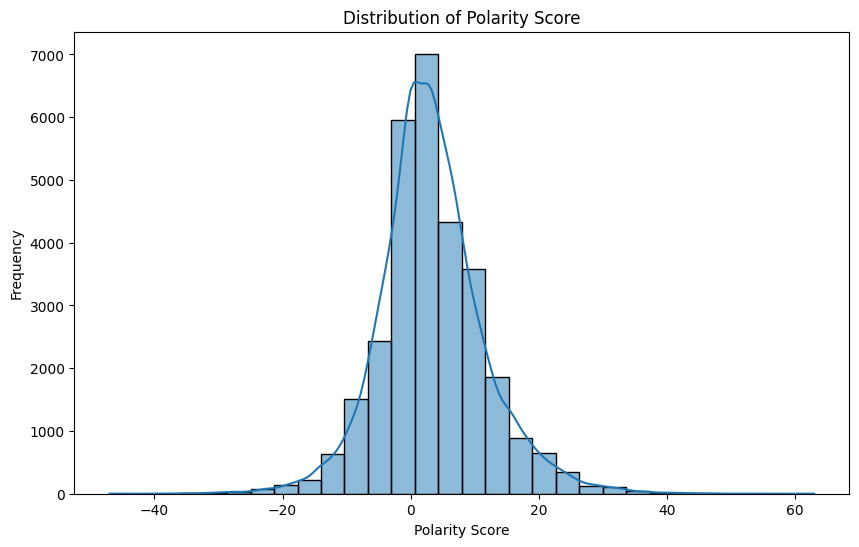

In [21]:
# Menampilkan distribusi polarity_score dengan histogram
plt.figure(figsize=(10, 6))  # Mengatur ukuran figure menjadi 10x6 inci
sns.histplot(clean_df['polarity_score'], bins=30, kde=True)  # Membuat histogram dengan 30 bin dan menampilkan kurva kepadatan (kde=True)
plt.title('Distribution of Polarity Score')  # Menambahkan judul grafik
plt.xlabel('Polarity Score')  # Memberikan label pada sumbu x
plt.ylabel('Frequency')  # Memberikan label pada sumbu y
plt.show()  # Menampilkan grafik


2. Menampilkan diagram lingkaran untuk memudahkan visualisasi pembagian dataset.

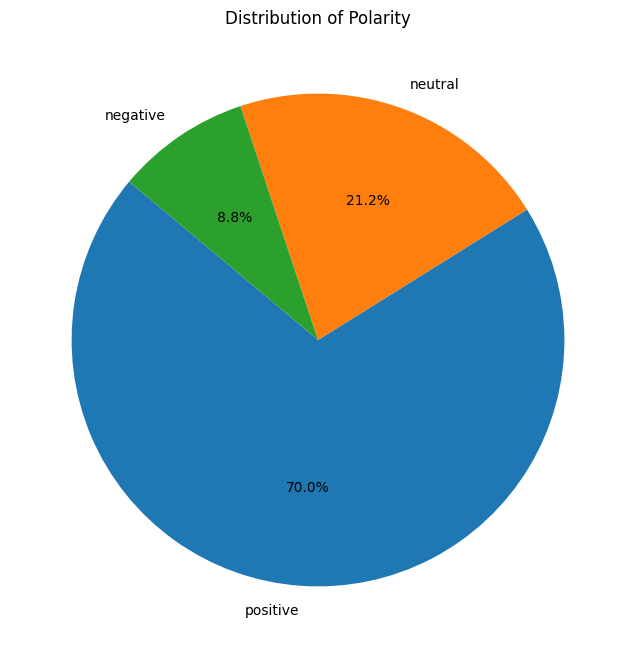

In [22]:
# Hitung jumlah masing-masing kategori polaritas
polarity_counts = clean_df['polarity'].value_counts()  # Menghitung jumlah setiap kategori polaritas (positive, neutral, negative)

# Menampilkan diagram lingkaran
plt.figure(figsize=(8, 8))  # Mengatur ukuran figure menjadi 8x8 inci
plt.pie(polarity_counts, labels=polarity_counts.index, autopct='%1.1f%%', startangle=140)
# Membuat diagram pie dengan label dari kategori polaritas, menampilkan persentase (%1.1f%%), dan memutar diagram dengan startangle 140 derajat
plt.title('Distribution of Polarity')  # Menambahkan judul diagram
plt.show()  # Menampilkan diagram pie


# Word cloud umum

1. Membuat wordcloud dari dataset tanpa melihat label.

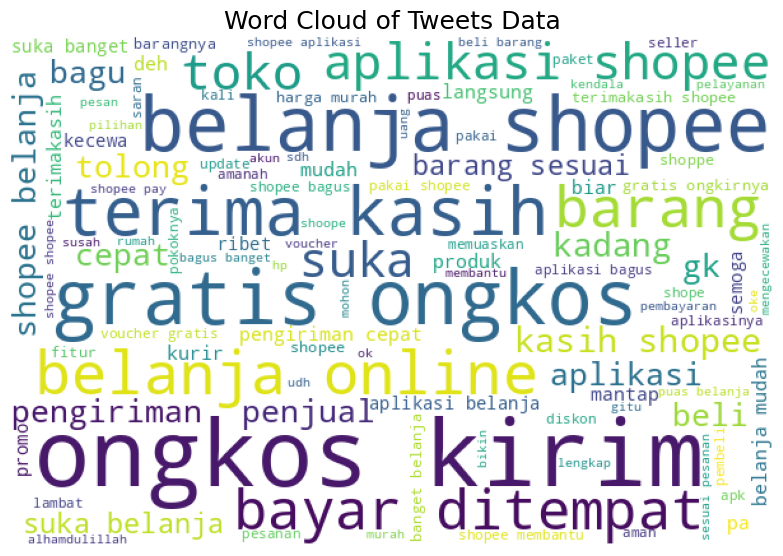

In [23]:
# Membuat wordcloud secara umum

list_words = ''

for tweet in clean_df['text_stopword']:
    # Iterasi melalui setiap tweet yang sudah difilter stopword.
    for word in tweet:
        # Menambahkan setiap kata ke dalam 'list_words' dengan spasi sebagai pemisah.
        list_words += ' ' + (word)

# Membuat word cloud dengan parameter tertentu
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))  # Membuat objek figure dan axis dengan ukuran 8x6 inci
ax.set_title('Word Cloud of Tweets Data', fontsize=18)  # Menambahkan judul untuk word cloud
ax.grid(False)  # Menghilangkan grid dari grafik
ax.imshow((wordcloud))  # Menampilkan word cloud pada axis
fig.tight_layout(pad=0)  # Mengatur tata letak agar lebih rapat
ax.axis('off')  # Menonaktifkan sumbu agar lebih bersih
plt.show()  # Menampilkan grafik word cloud


# Word cloud positive

In [24]:
# Mengatur opsi pandas agar kolom teks ditampilkan sepenuhnya
pd.set_option('display.max_colwidth', 3000)

# Memfilter tweet yang memiliki polaritas positif
positive_tweets = clean_df[clean_df['polarity'] == 'positive']

# Memilih kolom yang relevan untuk analisis
positive_tweets = positive_tweets[['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]

# Mengurutkan tweet berdasarkan skor polaritas secara descending (dari tinggi ke rendah)
positive_tweets = positive_tweets.sort_values(by='polarity_score', ascending=False)

# Mereset indeks setelah pengurutan
positive_tweets = positive_tweets.reset_index(drop=True)

# Mengubah indeks agar dimulai dari 1 (bukan dari 0)
positive_tweets.index += 1


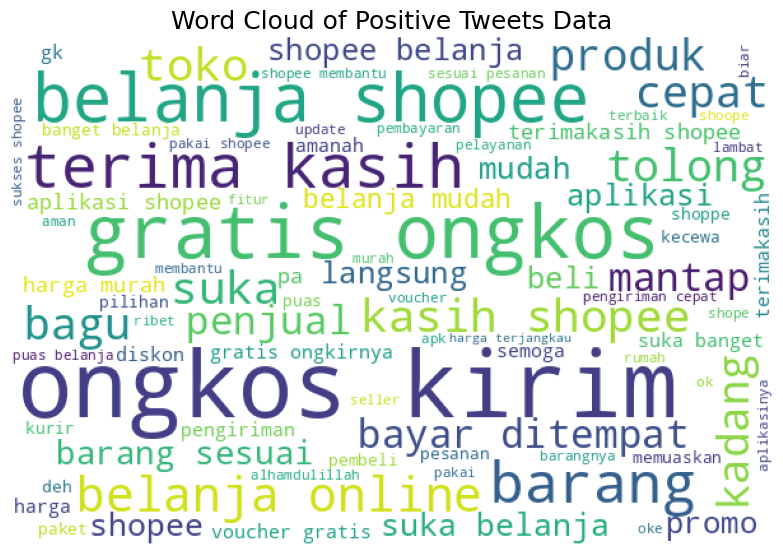

In [25]:
# Menampilkan wordcloud untuk label positive
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'positive_tweets'.
for tweet in positive_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat wordcloud berdasarkan kumpulan kata dari tweet positif
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat figure dan axis untuk menampilkan wordcloud
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul pada wordcloud
ax.set_title('Word Cloud of Positive Tweets Data', fontsize=18)

# Menonaktifkan grid pada plot
ax.grid(False)

# Menampilkan wordcloud yang telah dibuat
ax.imshow((wordcloud))

# Mengatur tata letak agar lebih rapih
fig.tight_layout(pad=0)

# Menonaktifkan sumbu pada plot
ax.axis('off')

# Menampilkan plot wordcloud
plt.show()


# Word cloud negative

In [26]:
# Membuat dataframe untuk wordcloud negative
pd.set_option('display.max_colwidth', 3000)  # Mengatur tampilan agar kolom teks panjang bisa terlihat

negative_tweets = clean_df[clean_df['polarity'] == 'negative']  # Memfilter tweet dengan polaritas negatif
negative_tweets = negative_tweets[['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]  # Memilih kolom yang diperlukan
negative_tweets = negative_tweets.sort_values(by='polarity_score', ascending=False)  # Mengurutkan berdasarkan skor polaritas tertinggi
negative_tweets = negative_tweets.reset_index(drop=True)  # Mengatur ulang indeks setelah penyortiran
negative_tweets.index += 1  # Mengubah indeks agar dimulai dari 1, bukan 0


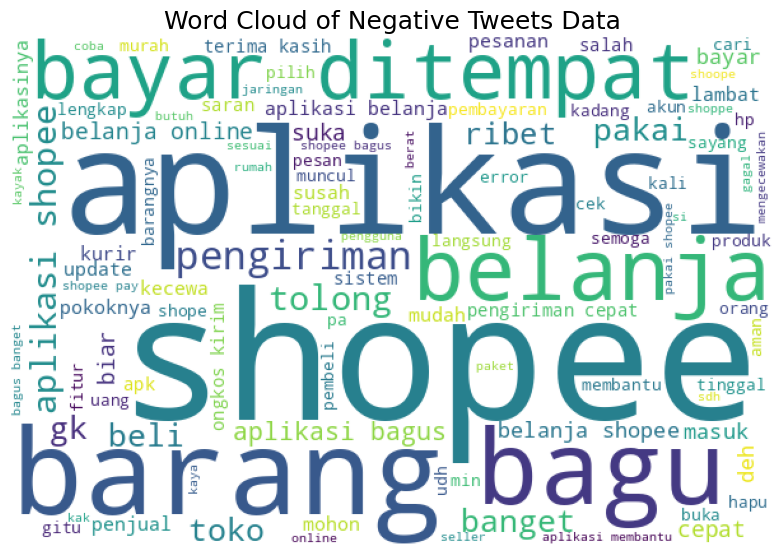

In [27]:
# Menampilkan wordcloud untuk label negative
list_words = ''  # Inisialisasi string kosong untuk menampung kata-kata

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'negative_tweets'.
for tweet in negative_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter yang ditentukan
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat figure untuk menampilkan wordcloud
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)  # Menambahkan judul grafik
ax.grid(False)  # Menghilangkan grid dari grafik
ax.imshow((wordcloud))  # Menampilkan wordcloud dalam figure
fig.tight_layout(pad=0)  # Mengatur tata letak agar tidak ada padding berlebih
ax.axis('off')  # Menonaktifkan sumbu agar lebih rapi

plt.show()  # Menampilkan plot


# word cloud neutral

In [28]:
# Mengatur lebar tampilan maksimum untuk kolom DataFrame agar dapat menampilkan teks panjang
pd.set_option('display.max_colwidth', 3000)

# Memfilter DataFrame 'clean_df' untuk mendapatkan tweet dengan label 'neutral'
neutral_tweets = clean_df[clean_df['polarity'] == 'neutral']

# Memilih hanya kolom yang relevan untuk dianalisis
neutral_tweets = neutral_tweets[['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]

# Mengurutkan tweet berdasarkan skor polaritas secara menurun (descending)
neutral_tweets = neutral_tweets.sort_values(by='polarity_score', ascending=False)

# Mereset indeks DataFrame setelah pengurutan agar berurutan kembali dari 1
neutral_tweets = neutral_tweets.reset_index(drop=True)
neutral_tweets.index += 1  # Mengubah indeks agar dimulai dari 1


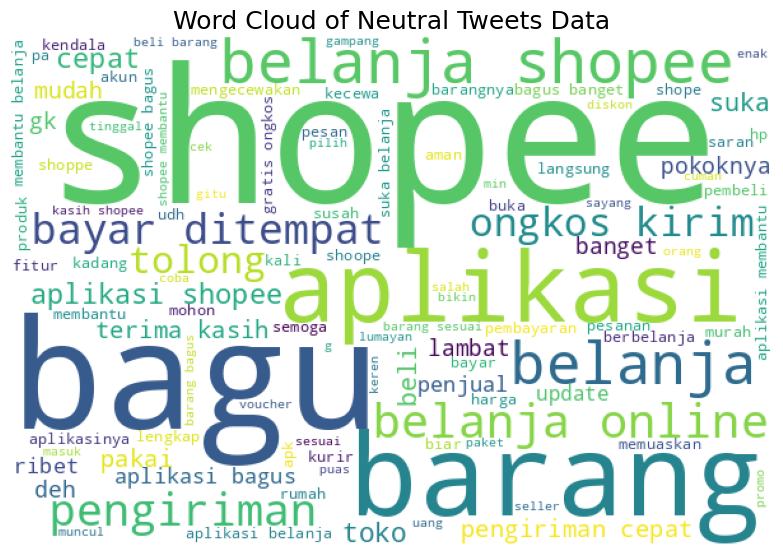

In [29]:
# Inisialisasi string kosong untuk menyimpan semua kata dari tweet dengan label 'neutral'
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'neutral_tweets'
for tweet in neutral_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words' dengan spasi sebagai pemisah
        list_words += ' ' + (word)

# Membuat word cloud dari kumpulan kata dalam 'list_words'
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat figure dan axes untuk menampilkan word cloud
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud
ax.set_title('Word Cloud of Neutral Tweets Data', fontsize=18)

# Menghilangkan grid pada tampilan
ax.grid(False)

# Menampilkan word cloud pada axes
ax.imshow((wordcloud))

# Menyesuaikan layout agar tidak ada padding berlebih
fig.tight_layout(pad=0)

# Menghilangkan sumbu (axis) agar tampilan lebih bersih
ax.axis('off')

# Menampilkan plot
plt.show()


# Visualisasi dataset

1. Menampilkan distribusi dari panjang text.

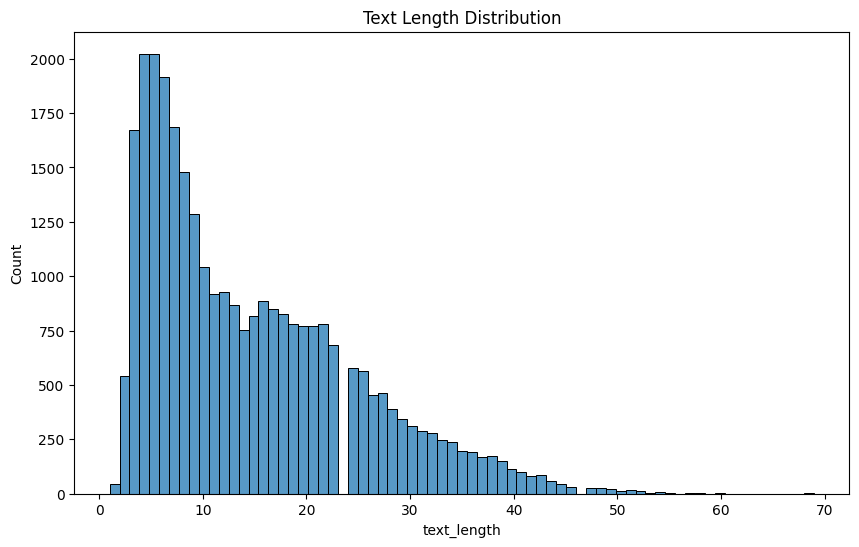

In [30]:
# Set ukuran figure untuk visualisasi
plt.figure(figsize=(10, 6))

# Menambahkan kolom baru 'text_length' untuk menyimpan jumlah kata dalam 'text_akhir'
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))

# Membuat histogram untuk mendistribusikan panjang teks dalam dataset
sns.histplot(clean_df['text_length'])

# Menambahkan judul pada plot
plt.title('Text Length Distribution')

# Menampilkan plot
plt.show()


2. Menampilkan kata yang paling sering muncul.

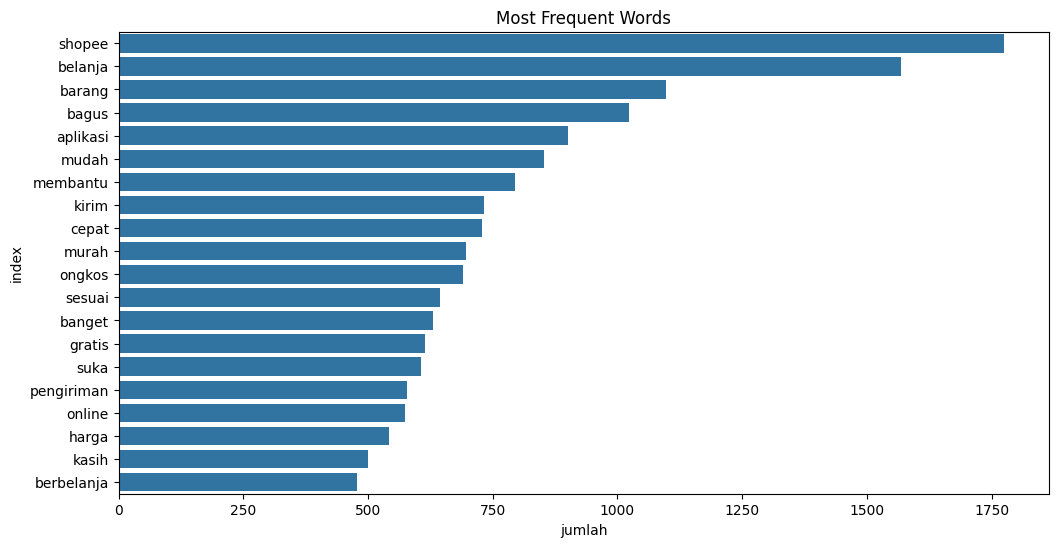

In [31]:
# Set ukuran figure untuk visualisasi
plt.figure(figsize=(12, 6))

# Menggunakan TfidfVectorizer untuk mendapatkan representasi kata berbasis TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])

# Mengubah hasil TF-IDF menjadi DataFrame dengan kata-kata sebagai kolom
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Menjumlahkan nilai TF-IDF dari setiap kata dalam semua dokumen
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')

# Mengurutkan kata berdasarkan jumlah kemunculan secara descending dan mengambil 20 kata teratas
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)

# Membuat visualisasi dengan barplot untuk menampilkan kata-kata yang paling sering muncul
sns.barplot(x='jumlah', y='index', data=tfidf_df)

# Menambahkan judul pada plot
plt.title('Most Frequent Words')

# Menampilkan plot
plt.show()


# Modeling

Pembuatan model dengan melakukan tiga percobaan skema pelatihan yang berbeda dan dibedakan dengan variasi dari dua kombinasi seperti berikut:

1. Model 1
  - Algoritma Pelatihan: LSTM
  - Pembagian Data: Training 70, val 20, test 10
2. Model 2
  - Algoritma Pelatihan: CNN
  - Pembagian Data: Training 80, val 10, test 10
3. Model 3
  - Algoritma Pelatihan: GRU
  - Pembagian Data: Training 90, val 5, test 5

Kolom text_akhir dijadikan sebagai fitur dan kolom polarity dijadikan sebagai target.

In [32]:
# Mengambil kolom text_akhir sebagai fitur (X) yang akan digunakan untuk pemodelan
X = clean_df['text_akhir']

# Mengambil kolom polarity sebagai label (y) untuk klasifikasi sentimen
y = clean_df['polarity']


Melakukan tokenisasi.

In [33]:
# Menentukan jumlah kata maksimal yang akan dipertimbangkan dalam tokenisasi
max_features = 2500

# Membuat tokenizer dengan batasan jumlah kata (max_features) dan menggunakan spasi sebagai pemisah kata
tokenizer = Tokenizer(num_words=max_features, split=' ')

# Melatih tokenizer dengan teks yang ada di X (mengonversi teks menjadi token)
tokenizer.fit_on_texts(X.values)

# Mengonversi teks ke dalam bentuk urutan angka berdasarkan tokenizer
X = tokenizer.texts_to_sequences(X.values)

# Melakukan padding agar semua urutan memiliki panjang yang sama
X = pad_sequences(X)

# Label encoding untuk mengubah label kategori menjadi angka
labelencoder = LabelEncoder()
integer_encoded = labelencoder.fit_transform(y)

# Mengonversi label yang telah dienkode ke dalam bentuk one-hot encoding
y = to_categorical(integer_encoded)

# Menentukan jumlah kelas yang akan digunakan dalam model
num_classes = y.shape[1]


Mendefinisikan callbacks yang akan berhenti jika nilai akurasi pelatihan > 0.95.

In [34]:
# Membuat class CustomCallback untuk menghentikan pelatihan jika val_accuracy melebihi 0.92
class CustomCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.92:  # Memeriksa nilai val_accuracy setelah setiap epoch
            print(f"\nVal accuracy telah melebihi 0.92, menghentikan pelatihan pada epoch {epoch+1}")
            self.model.stop_training = True  # Menghentikan pelatihan jika kondisi terpenuhi

# Inisialisasi callback early stopping dengan kriteria yang telah ditentukan
early_stopping = CustomCallback()


# Model 1 - LSTM

In [35]:
# Memisahkan data latih, validasi, dan uji
X_train_val, X_test_LSTM, y_train_val, y_test_LSTM = train_test_split(X, y, test_size=0.1, random_state=42)

X_train_LSTM, X_val_LSTM, y_train_LSTM, y_val_LSTM = train_test_split(X_train_val, y_train_val, test_size=2/9, random_state=42)

In [37]:
# Membangun model LSTM
model_LSTM = Sequential()
model_LSTM.add(Embedding(max_features, 256, input_length=X.shape[1]))
model_LSTM.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=l2(0.01), return_sequences=True))
model_LSTM.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=l2(0.01)))
model_LSTM.add(Dense(128, activation='relu'))
model_LSTM.add(Dense(64, activation='relu'))
model_LSTM.add(Dense(num_classes, activation='softmax'))
model_LSTM.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Melatih model dengan early stopping kustom
batch_size = 2056
history_LSTM = model_LSTM.fit(X_train_LSTM, y_train_LSTM, epochs=50, batch_size=batch_size, verbose=2, callbacks=[early_stopping], validation_data=(X_val_LSTM, y_val_LSTM))

Epoch 1/50
11/11 - 90s - 8s/step - accuracy: 0.6697 - loss: 5.3363 - val_accuracy: 0.7012 - val_loss: 4.4201
Epoch 2/50
11/11 - 77s - 7s/step - accuracy: 0.6998 - loss: 3.9070 - val_accuracy: 0.7012 - val_loss: 3.2664
Epoch 3/50
11/11 - 75s - 7s/step - accuracy: 0.6998 - loss: 2.8960 - val_accuracy: 0.7012 - val_loss: 2.4175
Epoch 4/50
11/11 - 80s - 7s/step - accuracy: 0.6998 - loss: 2.1455 - val_accuracy: 0.7022 - val_loss: 1.7843
Epoch 5/50
11/11 - 82s - 7s/step - accuracy: 0.7256 - loss: 1.5880 - val_accuracy: 0.7722 - val_loss: 1.3488
Epoch 6/50
11/11 - 80s - 7s/step - accuracy: 0.7793 - loss: 1.1814 - val_accuracy: 0.8137 - val_loss: 0.9895
Epoch 7/50
11/11 - 78s - 7s/step - accuracy: 0.8207 - loss: 0.8827 - val_accuracy: 0.8407 - val_loss: 0.7533
Epoch 8/50
11/11 - 74s - 7s/step - accuracy: 0.8523 - loss: 0.6669 - val_accuracy: 0.8490 - val_loss: 0.6098
Epoch 9/50
11/11 - 82s - 7s/step - accuracy: 0.8723 - loss: 0.5336 - val_accuracy: 0.8637 - val_loss: 0.5068
Epoch 10/50
11/11 -

In [38]:
# Evaluasi model
score_LSTM, acc_LSTM = model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose=2)
print("Test score: %.2f" % (score_LSTM))
print("Test accuracy: %.2f" % (acc_LSTM))

94/94 - 6s - 66ms/step - accuracy: 0.9077 - loss: 0.3652
Test score: 0.37
Test accuracy: 0.91


In [39]:
model_LSTM.save('model_LSTM.h5')

# Model 2 - CNN

In [40]:
# Memisahkan data latih, validasi, dan uji
X_train_val, X_test_CNN, y_train_val, y_test_CNN = train_test_split(X, y, test_size=0.1, random_state=42)

X_train_CNN, X_val_CNN, y_train_CNN, y_val_CNN = train_test_split(X_train_val, y_train_val, test_size=1/9, random_state=42)

In [42]:
# Membangun model CNN
model_CNN = Sequential()
model_CNN.add(Embedding(max_features, 512, input_length=X.shape[1]))
model_CNN.add(Conv1D(64, kernel_size=5, activation='relu'))
model_CNN.add(MaxPooling1D(pool_size=2))
model_CNN.add(Flatten())
model_CNN.add(Dense(64, activation='relu'))
model_CNN.add(Dropout(0.5))
model_CNN.add(Dense(num_classes, activation='softmax'))
model_CNN.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Melatih model dengan early stopping kustom
batch_size = 2056
history_CNN = model_CNN.fit(X_train_CNN, y_train_CNN, epochs=50, batch_size=batch_size, verbose=2, callbacks=[early_stopping], validation_data=(X_val_CNN, y_val_CNN))


Epoch 1/50
12/12 - 55s - 5s/step - accuracy: 0.6566 - loss: 0.8566 - val_accuracy: 0.7063 - val_loss: 0.7563
Epoch 2/50
12/12 - 83s - 7s/step - accuracy: 0.6983 - loss: 0.7593 - val_accuracy: 0.7063 - val_loss: 0.6880
Epoch 3/50
12/12 - 53s - 4s/step - accuracy: 0.7037 - loss: 0.6547 - val_accuracy: 0.7333 - val_loss: 0.5761
Epoch 4/50
12/12 - 81s - 7s/step - accuracy: 0.7404 - loss: 0.5464 - val_accuracy: 0.7630 - val_loss: 0.5132
Epoch 5/50
12/12 - 82s - 7s/step - accuracy: 0.7682 - loss: 0.4833 - val_accuracy: 0.7797 - val_loss: 0.4774
Epoch 6/50
12/12 - 82s - 7s/step - accuracy: 0.7905 - loss: 0.4421 - val_accuracy: 0.7857 - val_loss: 0.4555
Epoch 7/50
12/12 - 80s - 7s/step - accuracy: 0.8104 - loss: 0.4140 - val_accuracy: 0.8210 - val_loss: 0.4468
Epoch 8/50
12/12 - 84s - 7s/step - accuracy: 0.8435 - loss: 0.3825 - val_accuracy: 0.8257 - val_loss: 0.4476
Epoch 9/50
12/12 - 82s - 7s/step - accuracy: 0.8532 - loss: 0.3550 - val_accuracy: 0.8380 - val_loss: 0.4346
Epoch 10/50
12/12 -

In [43]:
# Evaluasi model
score_CNN, acc_CNN = model_CNN.evaluate(X_test_CNN, y_test_CNN, verbose=2,batch_size=1028)
print("Test score: %.2f" % (score_CNN))
print("Test accuracy: %.2f" % (acc_CNN))

3/3 - 2s - 607ms/step - accuracy: 0.8163 - loss: 1.3961
Test score: 1.40
Test accuracy: 0.82


In [44]:
model_CNN.save('model_CNN.h5')

# Model 3 - GRU

In [45]:
# Memisahkan data latih, validasi, dan uji
X_train_val, X_test_GRU, y_train_val, y_test_GRU = train_test_split(X, y, test_size=0.05, random_state=42)
X_train_GRU, X_val_GRU, y_train_GRU, y_val_GRU = train_test_split(X_train_val, y_train_val, test_size=0.0526, random_state=42)

In [46]:
# Membangun model GRU
model_GRU = Sequential()
model_GRU.add(Embedding(max_features, 512, input_length=X.shape[1]))
model_GRU.add(SpatialDropout1D(0.3))
model_GRU.add(Bidirectional(GRU(64, return_sequences=True)))
model_GRU.add(Bidirectional(GRU(128, return_sequences=False)))
model_GRU.add(Dense(128, activation='relu',kernel_regularizer=l2(0.01)))
model_GRU.add(Dropout(0.5))
model_GRU.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
model_GRU.add(Dropout(0.5))
model_GRU.add(Dense(num_classes, activation='softmax'))
model_GRU.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Melatih model dengan early stopping kustom
batch_size = 1028
history_GRU = model_GRU.fit(X_train_GRU, y_train_GRU, epochs=10, batch_size=batch_size, verbose=2, validation_data=(X_val_GRU, y_val_GRU),callbacks=[early_stopping])

Epoch 1/10
27/27 - 190s - 7s/step - accuracy: 0.6489 - loss: 2.8614 - val_accuracy: 0.6940 - val_loss: 2.0886
Epoch 2/10
27/27 - 212s - 8s/step - accuracy: 0.7867 - loss: 1.6286 - val_accuracy: 0.8493 - val_loss: 1.1725
Epoch 3/10
27/27 - 186s - 7s/step - accuracy: 0.8722 - loss: 0.9491 - val_accuracy: 0.8940 - val_loss: 0.7426
Epoch 4/10
27/27 - 204s - 8s/step - accuracy: 0.9104 - loss: 0.6064 - val_accuracy: 0.9047 - val_loss: 0.5251
Epoch 5/10
27/27 - 173s - 6s/step - accuracy: 0.9254 - loss: 0.4268 - val_accuracy: 0.9040 - val_loss: 0.4266
Epoch 6/10
27/27 - 172s - 6s/step - accuracy: 0.9413 - loss: 0.3175 - val_accuracy: 0.9007 - val_loss: 0.3841
Epoch 7/10
27/27 - 202s - 7s/step - accuracy: 0.9533 - loss: 0.2446 - val_accuracy: 0.8980 - val_loss: 0.3692
Epoch 8/10
27/27 - 202s - 7s/step - accuracy: 0.9516 - loss: 0.2189 - val_accuracy: 0.9060 - val_loss: 0.3418
Epoch 9/10
27/27 - 203s - 8s/step - accuracy: 0.9609 - loss: 0.1837 - val_accuracy: 0.9053 - val_loss: 0.3385
Epoch 10/1

In [47]:
# Evaluasi model
score_GRU, acc_GRU = model_GRU.evaluate(X_test_GRU, y_test_GRU, verbose=2)
print("Test score: %.2f" % (score_GRU))
print("Test accuracy: %.2f" % (acc_GRU))

47/47 - 3s - 72ms/step - accuracy: 0.9080 - loss: 0.3357
Test score: 0.34
Test accuracy: 0.91


In [48]:
# Menyimpan model
model_GRU.save('model_GRU.h5')

# Evaluasi model

In [49]:
results_df = pd.DataFrame({
    'Model': ['LSTM', 'CNN', 'GRU'],
    'Accuracy Train': [history_LSTM.history['accuracy'][-1], history_CNN.history['accuracy'][-1],history_GRU.history['accuracy'][-1]],
    'Accuracy Test': [acc_LSTM, acc_CNN,acc_GRU]
})
results_df

,Model,Accuracy Train,Accuracy Test
0,LSTM,0.975619,0.907667
1,CNN,0.980875,0.816333
2,GRU,0.964481,0.908000


# Predict

In [50]:
# Contoh data baru
new_texts = [
    "pemakai shoppe temukan penjual barang bagus penjual berkualitas original pakaian gadget sparepart sepeda motor sedih fitur kurir rekomendasi gratis ongkos kirim bikin paket layanan berbayar murah gratisan bagus dunia harap shoppe bikin promo gimmick bikin customer pindah app miss shoppe",
    "kurir sicepat ganti nama si lambat si lambat shoppe bagus langganan pke aplikasi tokped bawa nama jelek kurir sicepat min tolong kasih peringatan sicepat nakal kurirnya ngirimnya lambaaaaattttt kali",
    "saran belanja kurir rekomendasi pengirimannya komplain alasannya follow perkembangansaran free ongkos kirim pakai salah kurir kurir kurir"
]

# Nilai asli dari teks
true_labels = ["positive", "negative", "neutral"]

# Tokenisasi teks baru
new_sequences = tokenizer.texts_to_sequences(new_texts)
new_padded_sequences = pad_sequences(new_sequences, maxlen=X.shape[1])

# Membuat prediksi
predictions_LSTM = model_LSTM.predict(new_padded_sequences)
predictions_CNN = model_CNN.predict(new_padded_sequences)
predictions_GRU = model_GRU.predict(new_padded_sequences)

# Mengubah prediksi menjadi label
predicted_labels_LSTM = np.argmax(predictions_LSTM, axis=1)
predicted_labels_CNN = np.argmax(predictions_CNN, axis=1)
predicted_labels_GRU = np.argmax(predictions_GRU, axis=1)

predicted_labels_LSTM = labelencoder.inverse_transform(predicted_labels_LSTM)
predicted_labels_CNN = labelencoder.inverse_transform(predicted_labels_CNN)
predicted_labels_GRU = labelencoder.inverse_transform(predicted_labels_GRU)

# Menampilkan hasil prediksi
for text, true_label, label_LSTM, label_CNN, label_GRU in zip(new_texts, true_labels, predicted_labels_LSTM, predicted_labels_CNN, predicted_labels_GRU):
    print(f"Text: {text}\nTrue Label: {true_label}\nPredicted Label (LSTM): {label_LSTM}\nPredicted Label (CNN): {label_CNN}\nPredicted Label (GRU): {label_GRU}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 931ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Text: pemakai shoppe temukan penjual barang bagus penjual berkualitas original pakaian gadget sparepart sepeda motor sedih fitur kurir rekomendasi gratis ongkos kirim bikin paket layanan berbayar murah gratisan bagus dunia harap shoppe bikin promo gimmick bikin customer pindah app miss shoppe
True Label: positive
Predicted Label (LSTM): positive
Predicted Label (CNN): positive
Predicted Label (GRU): positive

Text: kurir sicepat ganti nama si lambat si lambat shoppe bagus langganan pke aplikasi tokped bawa nama jelek kurir sicepat min tolong kasih peringatan sicepat nakal kurirnya ngirimnya lambaaaaattttt kali
True Label: negative
Predicted Label (LSTM): negative
Predicted Label (CNN): negative
Predicted Label (GRU): negative

Text: saran belanja kurir rekomendasi pengirimannya komplain alasannya follow perkembangansaran free ongkos kirim pakai salah kurir kurir kurir
True 